<a href="https://colab.research.google.com/github/garvjain7/ai-ml-deeplearning-masterclass/blob/main/Deep_Learning_Masterclass_day1%262.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Deep Learning Masterclass — 2-Day Intensive
### *Written so anyone can follow — even without coding experience*

---

| | |
|---|---|
| **Day 1** | 1st April 2026 — What is a Neural Network? How does it learn? |
| **Day 2** | 2nd April 2026 — Why do networks fail? And how to fix every problem |
| **Each day** | 3 hours |

---

## 👋 Before We Start — Read This

This notebook is written for **two types of readers**:

| You are… | What to focus on |
|---|---|
| 🟢 Complete beginner / layman | Read every markdown explanation. The code is just "proof" — you don't have to understand every line |
| 🔵 Basic ML student | Read everything + understand the code comments |

> 💬 **Every single choice in this notebook is explained.** You will never see code that just says `Adam()` without a story of *why Adam* and not something simpler.

---

## 📖 The One Idea You Need Going In

You already understand this, even if you don't know it:

> A **thermostat** controls room temperature.
> It measures current temperature, compares to target, adjusts heating.
> It *learns* the right setting by correcting mistakes.

A neural network does the **exact same thing** — but for recognising images, detecting cancer, translating language.
It makes a guess → measures how wrong it is → adjusts itself → repeat.

Everything in this notebook is just making that loop smarter.

---

---
# 📅 DAY 1 — Neural Networks & How They Learn
## 1st April 2026  |  3 Hours

### 🗓 What We Cover Today

| Time | Topic | The Question We Answer |
|------|-------|----------------------|
| 0:30–1:00 | Why neural networks? | What can't simpler models do? |
| 1:00–1:30 | Activation functions | Why does the network need non-linearity? |
| 1:30–1:40 | Forward pass + Loss | How does data flow? How do we measure mistakes? |
| ☕ 1:40–1:45 | Break | — |
| 1:45–2:30 | Backpropagation | How does the network fix its mistakes? |
| 2:30–3:00 | Live demo | Watch a network learn XOR from scratch |

---

## 🔧 Run This First — Setup

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  SETUP
#  We only need three libraries today.
#  numpy  → all the maths (matrices, dot products, etc.)
#  matplotlib → all the pictures / charts
#  No PyTorch, no TensorFlow — we build everything by hand today
#  so you see exactly what those libraries hide from you.
# ══════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Fix randomness so every student gets identical results
np.random.seed(42)

# Slightly nicer plots
plt.rcParams.update({'figure.figsize':(11,4), 'font.size':12,
                     'axes.spines.top':False, 'axes.spines.right':False})

print("✅  All good — let's go!")

✅  All good — let's go!


---
## ⏱ 0:00 – 0:30 | Section 1: Why Do We Need Neural Networks?

### 🧩 Story First

Imagine you're a doctor trying to diagnose whether a tumour is **malignant or benign**.
You have measurements: size, shape, texture, etc.

A simple rule might be: *"if radius > 15mm, it's probably malignant"*.

That works sometimes. But real cancer doesn't follow a single rule.
It's a **complex combination** of many measurements interacting together.

You need a model that can learn those complex combinations automatically.
That's a neural network.

---

### 🔴 The Problem with Logistic Regression (What You Already Know)

Logistic regression draws **one straight line** (or flat plane) to separate classes.

$$\hat{y} = \sigma(w_1 x_1 + w_2 x_2 + \ldots + b)$$

This completely fails when the boundary is curved or complex.

**Classic proof — XOR:**

| x₁ | x₂ | Output |
|---|---|---|
| 0 | 0 | 0 |
| 0 | 1 | **1** |
| 1 | 0 | **1** |
| 1 | 1 | 0 |

You cannot draw one straight line separating the 1s from the 0s. Try it.

---

### ✅ The Neural Network Solution: Stack Layers

Instead of one transformation, do several in sequence:

$$\hat{y} = f_3\!\Big(f_2\!\big(f_1(x)\big)\Big)$$

Each layer $f_i$ learns a different **view** of the data.
Later layers combine earlier views into complex patterns.

> 🧠 **Analogy — recognising a cat in a photo:**
> Layer 1 sees edges → Layer 2 sees shapes (ears, eyes) → Layer 3 says "that's a cat"
> Each layer only has to do a small, simple job.

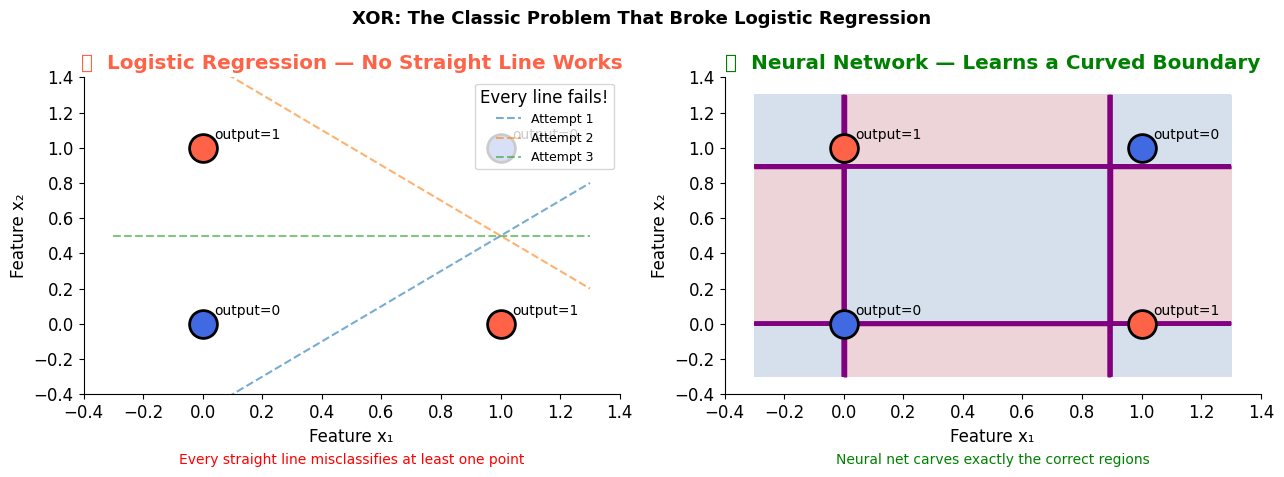

💡  The curved boundary is possible because of ACTIVATION FUNCTIONS.
    That's the next section.


In [ ]:
# ══════════════════════════════════════════════════════════════════
#  PICTURE: Why logistic regression cannot solve XOR
#  but a neural network can.
#  (You don't need to understand this code — just run it and look)
# ══════════════════════════════════════════════════════════════════

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13,5))

# The four XOR data points
xor_points = [(0,0,0),(0,1,1),(1,0,1),(1,1,0)]  # (x1, x2, label)
colors = {0:'royalblue', 1:'tomato'}

for ax in [ax1, ax2]:
    for x1,x2,lbl in xor_points:
        ax.scatter(x1,x2, color=colors[lbl], s=400, zorder=5,
                   edgecolors='black', linewidths=2)
        ax.annotate(f"output={lbl}", (x1,x2),
                    xytext=(x1+0.04, x2+0.05), fontsize=10)
    ax.set_xlim(-0.4,1.4); ax.set_ylim(-0.4,1.4)
    ax.set_xlabel("Feature x₁"); ax.set_ylabel("Feature x₂")

# Left: show that NO straight line works
ax1.set_title("❌  Logistic Regression — No Straight Line Works",
              fontweight='bold', color='tomato')
xv = np.linspace(-0.3,1.3,100)
for s,b,name in [(1,-0.5,'Attempt 1'),(-1,1.5,'Attempt 2'),(0,0.5,'Attempt 3')]:
    ax1.plot(xv, s*xv+b, '--', alpha=0.6, label=name)
ax1.legend(title="Every line fails!", fontsize=9)
ax1.text(0.5,-0.22,
    "Every straight line misclassifies at least one point",
    ha='center', color='red', fontsize=10, transform=ax1.transAxes)

# Right: neural network draws a curved boundary
ax2.set_title("✅  Neural Network — Learns a Curved Boundary",
              fontweight='bold', color='green')
xx,yy = np.meshgrid(np.linspace(-0.3,1.3,200),np.linspace(-0.3,1.3,200))
grid  = np.c_[xx.ravel(),yy.ravel()]
Z = (np.sin(grid[:,0]*3.5)*np.sin(grid[:,1]*3.5)>0).reshape(xx.shape).astype(float)
ax2.contourf(xx,yy,Z, alpha=0.18, cmap='RdBu')
ax2.contour( xx,yy,Z, colors='purple', linewidths=2.5)
ax2.text(0.5,-0.22,
    "Neural net carves exactly the correct regions",
    ha='center', color='green', fontsize=10, transform=ax2.transAxes)

plt.suptitle("XOR: The Classic Problem That Broke Logistic Regression",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("💡  The curved boundary is possible because of ACTIVATION FUNCTIONS.")
print("    That's the next section.")

---
## ⏱ 0:30 – 1:00 | Section 2: Activation Functions

### 🧩 Why Do We Even Need Them?

Without activation functions, stacking layers is pointless.

Here is why: any combination of linear operations is still linear.

$$W_3 \cdot \big(W_2 \cdot (W_1 x)\big) = \underbrace{(W_3 W_2 W_1)}_{\text{one big }W} \cdot x$$

No matter how many layers — you still get one straight line.

**Activation functions inject non-linearity** so each layer can genuinely do something new.

---

### 🎛 The Four Functions You Need to Know

#### 1. Sigmoid — the "squisher"
$$\sigma(z) = \frac{1}{1+e^{-z}}, \quad \text{output} \in (0,1)$$

- 📌 **Use for:** Output layer of binary classifiers (gives a probability)
- ⚠️ **Avoid in hidden layers:** its gradient is at most **0.25**
  → after 5 layers: $0.25^5 = 0.001$ — gradient almost gone → network stops learning

---

#### 2. Tanh — the "zero-centred squisher"
$$\tanh(z), \quad \text{output} \in (-1, 1)$$

- 📌 Better than sigmoid for hidden layers (zero-centred = more balanced gradients)
- ⚠️ Still saturates at extremes

---

#### 3. ReLU — the simple winner
$$\text{ReLU}(z) = \max(0, z)$$

- 📌 **Default choice for hidden layers** — fast, no saturation for positive inputs
- ⚠️ **Dying ReLU:** if a neuron always gets negative input, it outputs 0 forever and stops learning

---

#### 4. Leaky ReLU — fixes dying neurons
$$\text{LeakyReLU}(z) = \max(0.01z,\; z)$$

- 📌 Same as ReLU but negative inputs still get a tiny gradient (0.01)
- Use when you notice many neurons "stuck at zero"

---

> 🏆 **Simple rule for beginners:**
> - Hidden layers → **ReLU**
> - Output layer (binary) → **Sigmoid**
> - Only change if you see a specific problem

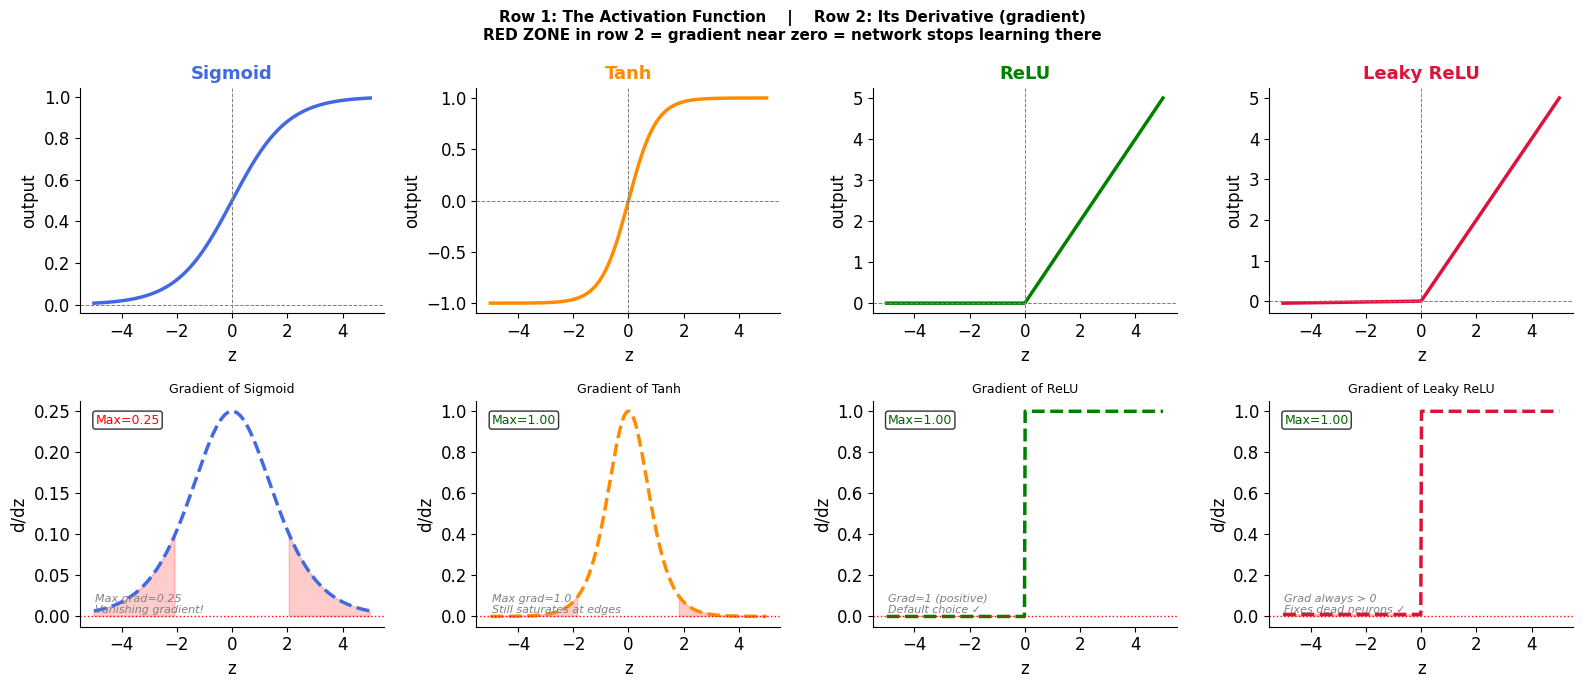


📌 TAKEAWAY:
  Sigmoid hidden layers → gradient shrinks to 0.25 each layer → vanishes fast
  ReLU hidden layers    → gradient stays 1.0 (positive side) → flows freely


In [ ]:
# ══════════════════════════════════════════════════════════════════
#  Define the 4 activation functions.
#  Each one also returns its DERIVATIVE — needed for backpropagation.
#
#  WHY do we need derivatives?
#  → Backprop multiplies gradient by the derivative at each layer.
#  → If derivative ≈ 0 everywhere → gradient vanishes → no learning.
#  → This is called the VANISHING GRADIENT problem.
# ══════════════════════════════════════════════════════════════════

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_grad(z):
    s = sigmoid(z)
    return s * (1 - s)          # Max value = 0.25  ← this is the problem

def tanh_act(z):
    return np.tanh(z)

def tanh_grad(z):
    return 1 - np.tanh(z)**2    # Max value = 1.0  ← better

def relu(z):
    return np.maximum(0, z)

def relu_grad(z):
    return (z > 0).astype(float) # 1 if positive, 0 if negative

def leaky_relu(z, a=0.01):
    return np.where(z > 0, z, a*z)

def leaky_relu_grad(z, a=0.01):
    return np.where(z > 0, 1.0, a)  # Never zero ← fixes dying ReLU


# ══════════════════════════════════════════════════════════════════
#  PICTURE: Show each function AND its derivative side by side.
#
#  The DERIVATIVE row is the most important:
#  → Red shaded zone = derivative near 0 = learning stops there.
#  → The bigger and flatter the derivative, the better learning flows.
# ══════════════════════════════════════════════════════════════════

z = np.linspace(-5, 5, 400)

configs = [
    (sigmoid,     sigmoid_grad,     'Sigmoid',     'royalblue',
     'Max grad=0.25\nVanishing gradient!'),
    (tanh_act,    tanh_grad,        'Tanh',        'darkorange',
     'Max grad=1.0\nStill saturates at edges'),
    (relu,        relu_grad,        'ReLU',        'green',
     'Grad=1 (positive)\nDefault choice ✓'),
    (leaky_relu,  leaky_relu_grad,  'Leaky ReLU',  'crimson',
     'Grad always > 0\nFixes dead neurons ✓'),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle(
    """Row 1: The Activation Function    |    Row 2: Its Derivative (gradient)
RED ZONE in row 2 = gradient near zero = network stops learning there""",
    fontsize=11, fontweight='bold')

for col,(fn,fd,name,c,note) in enumerate(configs):
    # ── Row 1: the activation ──────────────────────────────────
    ax = axes[0,col]
    ax.plot(z, fn(z), color=c, lw=2.5)
    ax.axhline(0, color='gray', lw=0.7, ls='--')
    ax.axvline(0, color='gray', lw=0.7, ls='--')
    ax.set_title(name, fontweight='bold', color=c, fontsize=13)
    ax.set_xlabel('z'); ax.set_ylabel('output')

    # ── Row 2: the derivative ──────────────────────────────────
    ax2 = axes[1,col]
    gv = fd(z)
    ax2.plot(z, gv, color=c, lw=2.5, ls='--')
    ax2.fill_between(z, gv, 0,
                     where=(np.abs(gv)<0.1),
                     color='red', alpha=0.2, label='Danger zone')
    ax2.axhline(0, color='red', lw=1, ls=':')
    ax2.set_xlabel('z'); ax2.set_ylabel("d/dz")
    ax2.set_title(f'Gradient of {name}', fontsize=9)
    mg = np.max(np.abs(gv))
    ax2.text(0.05, 0.90, f'Max={mg:.2f}',
             transform=ax2.transAxes, fontsize=9,
             color='darkgreen' if mg>=0.9 else 'red',
             bbox=dict(boxstyle='round,pad=0.2',facecolor='white',alpha=0.8))
    ax2.text(0.05, 0.06, note, transform=ax2.transAxes,
             fontsize=8, color='gray', style='italic')

plt.tight_layout(); plt.show()

print("\n📌 TAKEAWAY:")
print("  Sigmoid hidden layers → gradient shrinks to 0.25 each layer → vanishes fast")
print("  ReLU hidden layers    → gradient stays 1.0 (positive side) → flows freely")

---
## ⏱ 1:00 – 1:30 | Section 3: Forward Pass & Loss Functions

### 🧩 How Data Travels Through the Network

Think of a network as a **pipeline of transformations**:

```
Input X  →  Layer 1  →  Layer 2  →  Layer 3  →  Prediction ŷ
```

At each layer, two simple steps:

**Step 1 — Mix the inputs (linear):**
$$Z = W \cdot A_{\text{prev}} + b$$

*W is a weight matrix, A_prev is what came out of the previous layer, b is a bias.*

**Step 2 — Apply activation (non-linear):**
$$A = \text{activation}(Z)$$

We save both $Z$ and $A$ — we'll need them when learning from mistakes.

---

### 📏 Loss Functions — "How Wrong Are We?"

After the forward pass, we need a **single number** measuring the error.

#### For classification (is this tumour malignant?) → Binary Cross-Entropy (BCE)
$$L = -\frac{1}{m}\sum\left[y \cdot \log(\hat{y}) + (1-y)\cdot\log(1-\hat{y})\right]$$

#### For regression (predict a price) → Mean Squared Error (MSE)
$$L = \frac{1}{m}\sum(\hat{y} - y)^2$$

> 🤔 **Why not use MSE for classification?**
>
> Say the true label is 1 (malignant) and the network predicts 0.01 (almost certainly benign).
> - MSE penalty: $(0.01-1)^2 = 0.98$ — moderate
> - BCE penalty: $-\log(0.01) = 4.6$ — **enormous**
>
> Cross-entropy punishes confident wrong answers dramatically more.
> This forces the network to really learn — not just approximately guess.

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  LOSS FUNCTIONS
#  Simple implementations, each with a "why" comment.
# ══════════════════════════════════════════════════════════════════

def binary_cross_entropy(y_pred, y_true, eps=1e-8):
    """
    Binary Cross-Entropy — use for YES/NO classification tasks.

    The log() function is the key ingredient:
      • Predicting 0.99 when true=1  → -log(0.99) ≈ 0.01   tiny penalty
      • Predicting 0.50 when true=1  → -log(0.50) ≈ 0.69   moderate
      • Predicting 0.01 when true=1  → -log(0.01) ≈ 4.60   HUGE penalty

    Confident wrong answers are penalised catastrophically.
    This is why neural networks learn to be genuinely confident.

    eps: clips predictions away from 0 and 1 to avoid log(0) = -infinity.
    """
    y_pred = np.clip(y_pred, eps, 1-eps)
    return -np.mean(y_true * np.log(y_pred) + (1-y_true) * np.log(1-y_pred))

def mse_loss(y_pred, y_true):
    """Mean Squared Error — use for predicting a continuous number."""
    return np.mean((y_pred - y_true)**2)


# ══════════════════════════════════════════════════════════════════
#  DEMO: Show concretely why BCE beats MSE for classification.
# ══════════════════════════════════════════════════════════════════

print("  How different loss functions penalise a wrong prediction")
print("  (True label = 1  in all rows below)")
print()
print(f"  {'Scenario':<32} {'Prediction':>12} {'MSE':>8} {'BCE':>10}")
print("  " + "─"*65)

rows = [
    ("Correct & very confident",      0.99),
    ("Correct but uncertain",          0.60),
    ("Wrong — uncertain",              0.40),
    ("Wrong & very confident",         0.01),
]
for desc, p in rows:
    m = mse_loss(np.array([p]),   np.array([1.0]))
    b = binary_cross_entropy(np.array([p]), np.array([1.0]))
    flag = "  ← BCE screams here!" if p < 0.1 else ""
    print(f"  {desc:<32} {p:>12.2f} {m:>8.3f} {b:>10.3f}{flag}")

print()
print("  💡  For 'Wrong & very confident': BCE is 4.7× larger than MSE.")
print("      This aggressive penalty forces the network to really learn,")
print("      not just get 'close enough'.")

  How different loss functions penalise a wrong prediction
  (True label = 1  in all rows below)

  Scenario                           Prediction      MSE        BCE
  ─────────────────────────────────────────────────────────────────
  Correct & very confident                 0.99    0.000      0.010
  Correct but uncertain                    0.60    0.160      0.511
  Wrong — uncertain                        0.40    0.360      0.916
  Wrong & very confident                   0.01    0.980      4.605  ← BCE screams here!

  💡  For 'Wrong & very confident': BCE is 4.7× larger than MSE.
      This aggressive penalty forces the network to really learn,
      not just get 'close enough'.


---
## ⏱ 1:45 – 2:30 | Section 4: Backpropagation *(after break)*

### 🧩 The Big Idea — A Simple Story

Imagine you're a student who just got an exam back.
You got question 5 wrong. Now you need to figure out:
- Which part of your thinking led to the mistake?
- How should you adjust your understanding?

You trace **backwards** through your reasoning:
"My final answer was wrong because of step 3, which was wrong because of step 1."

A neural network does the **exact same thing** — traces the error backwards through each layer to figure out how much each weight contributed to the mistake.

---

### 🔢 The Chain Rule (in plain language)

If A affects B, and B affects C, then:
*"How much does A affect C?"* = *"How much does A affect B"* × *"How much does B affect C"*

$$\frac{\partial C}{\partial A} = \frac{\partial C}{\partial B} \cdot \frac{\partial B}{\partial A}$$

Backpropagation applies this rule, layer by layer, from output back to input.

---

### 📐 The Three Equations

**Define: error signal** $\delta^{[l]}$ = "how much does the loss care about layer $l$?"

**Output layer** (sigmoid + BCE simplifies beautifully to just):
$$\delta^{[L]} = \hat{y} - y$$

**Hidden layers** (chain rule propagating backward):
$$\delta^{[l]} = \underbrace{\left(W^{[l+1]T} \cdot \delta^{[l+1]}\right)}_{\text{error from next layer}} \odot \underbrace{g'(Z^{[l]})}_{\text{activation gradient}}$$

**Weight gradients:**
$$\frac{\partial L}{\partial W^{[l]}} = \frac{1}{m}\, \delta^{[l]} \cdot A^{[l-1]T}$$

> 🔑 **Why transpose $W$?** Forward pass: $W$ routes signals from layer $l$ → $l+1$.
> Backward pass: $W^T$ routes error *back* from $l+1$ → $l$.
> It's the same road, driven in reverse.

> 🔑 **Why multiply by $g'(Z)$?** We can only send error through neurons that were actually "on". If a neuron was saturated (flat activation → $g'≈0$), no error flows back through it. This is exactly how vanishing gradients happen.

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  NEURAL NETWORK — COMPLETE, READABLE IMPLEMENTATION
#
#  This is the whole thing: weights, forward pass, backward pass,
#  weight update — in one class, every line commented.
#
#  Don't be scared by the length. Each method is only ~10 lines.
# ══════════════════════════════════════════════════════════════════

class SimpleNeuralNet:
    """
    A fully connected neural network using only NumPy.

    layer_sizes : list like [2, 4, 1]
        Means: 2 inputs → 4 hidden neurons → 1 output neuron
    lr : learning rate (step size, explained more in Day 2)
    """

    def __init__(self, layer_sizes, lr=0.1):
        self.sizes = layer_sizes
        self.lr    = lr
        self.L     = len(layer_sizes) - 1   # number of weight layers
        self.params = {}     # will hold W1,b1, W2,b2, ...
        self.cache  = {}     # will hold Z1,A1, Z2,A2, ... during forward pass
        self.history = []    # loss at each training step
        self._init_weights()

    # ── Step 0: Initialise weights ─────────────────────────────
    def _init_weights(self):
        """
        WHY NOT start all weights at zero?
        → Every neuron would compute the same thing.
          Every gradient would be equal. Every update identical.
          The network would never learn different features.
          (This is called the "symmetry problem".)

        WHY small random values?
        → Each neuron starts slightly different → can specialise.
        → Small values prevent activations from saturating immediately.

        (Day 2 covers much better initialisation: Xavier and He.)
        """
        np.random.seed(42)
        for l in range(1, self.L+1):
            n_in  = self.sizes[l-1]
            n_out = self.sizes[l]
            self.params[f'W{l}'] = np.random.randn(n_out, n_in) * 0.01
            self.params[f'b{l}'] = np.zeros((n_out, 1))

    # ── Step 1: Forward pass ───────────────────────────────────
    def forward(self, X):
        """
        Pass data from left (input) to right (output).
        At each layer: Z = W·A_prev + b,  then  A = activation(Z)
        Save everything — backprop will need it.
        """
        self.cache['A0'] = X
        A = X

        # Hidden layers use ReLU (WHY ReLU: gradient stays 1, not 0.25)
        for l in range(1, self.L):
            Z = self.params[f'W{l}'] @ A + self.params[f'b{l}']
            A = relu(Z)
            self.cache[f'Z{l}'] = Z   # saved for backprop
            self.cache[f'A{l}'] = A   # saved for backprop

        # Output layer uses Sigmoid (WHY: outputs a probability 0–1)
        Z = self.params[f'W{self.L}'] @ A + self.params[f'b{self.L}']
        A = sigmoid(Z)
        self.cache[f'Z{self.L}'] = Z
        self.cache[f'A{self.L}'] = A
        return A   # prediction, shape (1, n_samples)

    # ── Step 2: Backward pass ──────────────────────────────────
    def backward(self, y):
        """
        Trace the error backwards to find each weight's contribution.
        Returns a dict of gradients: dW1, db1, dW2, db2, ...
        """
        m = y.shape[1]    # number of training samples
        grads = {}

        # Output layer: for sigmoid + BCE loss, the gradient is simply ŷ - y
        # (The sigmoid and log derivatives cancel out neatly — a lucky coincidence)
        delta = self.cache[f'A{self.L}'] - y

        grads[f'dW{self.L}'] = (1/m) * delta @ self.cache[f'A{self.L-1}'].T
        grads[f'db{self.L}'] = (1/m) * np.sum(delta, axis=1, keepdims=True)

        # Hidden layers: propagate error backwards using chain rule
        for l in range(self.L-1, 0, -1):
            # Route error back through this layer's weights (transpose = reverse direction)
            # Then mask by which neurons were active (relu_grad)
            delta = (self.params[f'W{l+1}'].T @ delta) * relu_grad(self.cache[f'Z{l}'])

            grads[f'dW{l}'] = (1/m) * delta @ self.cache[f'A{l-1}'].T
            grads[f'db{l}'] = (1/m) * np.sum(delta, axis=1, keepdims=True)

        return grads

    # ── Step 3: Update weights ─────────────────────────────────
    def update(self, grads):
        """
        Move each weight in the direction that reduces loss.
        W = W - lr * gradient

        WHY subtract?
        Gradient points toward HIGHER loss.
        We want LOWER loss → go the opposite way.

        WHY multiply by lr (learning rate)?
        Controls how big a step we take.
        Too large → overshoot. Too small → too slow.
        Day 2 covers how to choose this well.
        """
        for l in range(1, self.L+1):
            self.params[f'W{l}'] -= self.lr * grads[f'dW{l}']
            self.params[f'b{l}'] -= self.lr * grads[f'db{l}']

    # ── Full training loop ─────────────────────────────────────
    def train(self, X, y, epochs=5000, verbose=True):
        """
        Repeat: forward → compute loss → backward → update.
        WHY many epochs? One pass adjusts weights slightly.
        Thousands of passes → converge to a good solution.
        """
        for epoch in range(epochs):
            y_pred = self.forward(X)
            loss   = binary_cross_entropy(y_pred.flatten(), y.flatten())
            self.history.append(loss)
            grads  = self.backward(y)
            self.update(grads)
            if verbose and epoch % (epochs//5) == 0:
                acc = (y_pred.round() == y).mean() * 100
                print(f"  Epoch {epoch:>6} | Loss: {loss:.4f} | Accuracy: {acc:.0f}%")

print("✅  SimpleNeuralNet ready!")
print()
print("  Three steps per training iteration:")
print("  1. forward()  — make a prediction")
print("  2. backward() — trace the error to each weight")
print("  3. update()   — nudge weights toward lower loss")

✅  SimpleNeuralNet ready!

  Three steps per training iteration:
  1. forward()  — make a prediction
  2. backward() — trace the error to each weight
  3. update()   — nudge weights toward lower loss


---
## ⏱ 2:30 – 3:00 | Section 5: 💻 Live Demo — Watch the Network Learn

We'll train our network on XOR.
- Epoch 0: accuracy around 50% (random guessing)
- By epoch 5000: accuracy should reach **100%**

This is backpropagation working in real time!

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  XOR DATASET
#  Columns are samples, rows are features (numpy convention)
# ══════════════════════════════════════════════════════════════════

X_xor = np.array([[0,0,1,1],
                   [0,1,0,1]])   # shape (2, 4)

y_xor = np.array([[0,1,1,0]])   # shape (1, 4) — true XOR output

# Architecture: 2 inputs → 4 hidden neurons → 1 output
# Why 4 hidden neurons? XOR only needs ~2, but 4 gives more room to learn.
net = SimpleNeuralNet(layer_sizes=[2, 4, 1], lr=0.5)

print("Training on XOR (watch loss fall, accuracy rise to 100%):")
print("─"*52)
net.train(X_xor, y_xor, epochs=5001)

print("─"*52)
print("\nFinal predictions:")
print(f"  {'(x1,x2)':<10} {'True':>6} {'Predicted Prob':>16} {'Decision':>10}")
print("  " + "─"*46)
preds = net.forward(X_xor)
for i in range(4):
    x1,x2 = X_xor[0,i], X_xor[1,i]
    true  = int(y_xor[0,i])
    prob  = float(preds[0,i])
    pred  = int(prob > 0.5)
    ok    = "✅" if pred==true else "❌"
    print(f"  ({x1},{x2})       {true:>6}    {prob:>10.4f}     {pred}  {ok}")

Training on XOR (watch loss fall, accuracy rise to 100%):
────────────────────────────────────────────────────
  Epoch      0 | Loss: 0.6931 | Accuracy: 75%
  Epoch   1000 | Loss: 0.0062 | Accuracy: 100%
  Epoch   2000 | Loss: 0.0023 | Accuracy: 100%
  Epoch   3000 | Loss: 0.0014 | Accuracy: 100%
  Epoch   4000 | Loss: 0.0010 | Accuracy: 100%
  Epoch   5000 | Loss: 0.0008 | Accuracy: 100%
────────────────────────────────────────────────────

Final predictions:
  (x1,x2)      True   Predicted Prob   Decision
  ──────────────────────────────────────────────
  (0,0)            0        0.0022     0  ✅
  (0,1)            1        0.9997     1  ✅
  (1,0)            1        0.9997     1  ✅
  (1,1)            0        0.0002     0  ✅


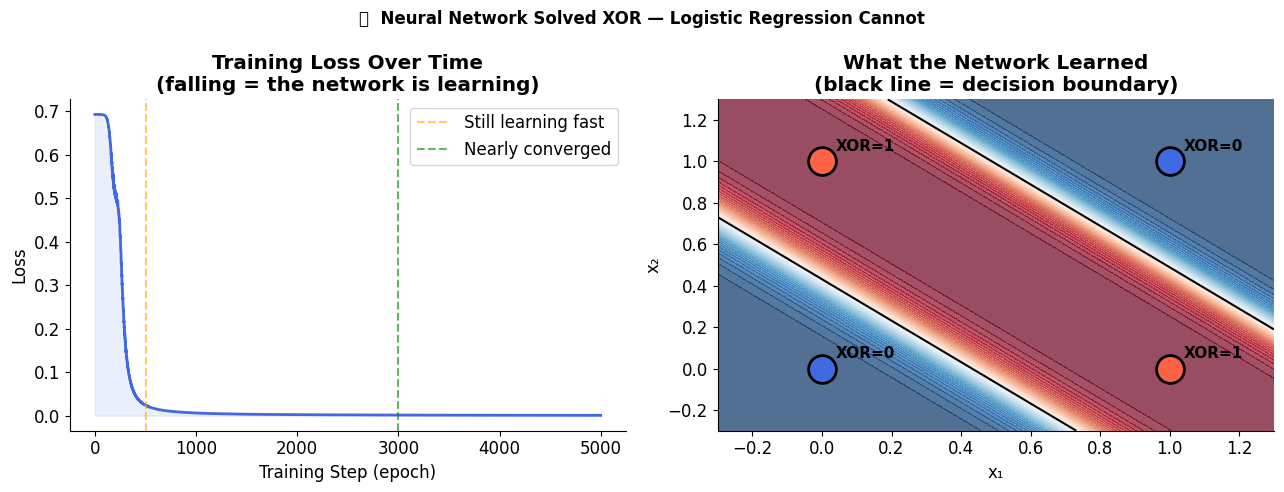

🏁  Day 1 complete!

  You built and understood:
  ✅  Why neural networks exist (XOR problem)
  ✅  What activation functions do and which to use
  ✅  How data flows forward through the network
  ✅  How backpropagation traces errors backward
  ✅  A working network trained on XOR from pure NumPy

  Tomorrow: why does training sometimes completely FAIL?
  And how to fix every single failure mode — using real cancer data.


In [ ]:
# ══════════════════════════════════════════════════════════════════
#  PICTURE: Training curve + learned decision boundary
# ══════════════════════════════════════════════════════════════════

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(13,5))

# ── Loss curve ──────────────────────────────────────────────────
ax1.plot(net.history, color='royalblue', lw=2)
ax1.fill_between(range(len(net.history)), net.history, alpha=0.1, color='royalblue')
ax1.set_xlabel('Training Step (epoch)'); ax1.set_ylabel('Loss')
ax1.set_title('Training Loss Over Time\n(falling = the network is learning)', fontweight='bold')
ax1.axvline(500,  color='orange', ls='--', alpha=0.6, label='Still learning fast')
ax1.axvline(3000, color='green',  ls='--', alpha=0.6, label='Nearly converged')
ax1.legend()

# ── Decision boundary ────────────────────────────────────────────
xx,yy = np.meshgrid(np.linspace(-0.3,1.3,200),np.linspace(-0.3,1.3,200))
grid  = np.c_[xx.ravel(),yy.ravel()].T
probs = net.forward(grid).reshape(xx.shape)
ax2.contourf(xx,yy,probs, levels=50, cmap='RdBu_r', alpha=0.7)
ax2.contour( xx,yy,probs, levels=[0.5], colors='black', lw=2.5)
colors2 = {0:'royalblue',1:'tomato'}
for i in range(4):
    x1,x2 = X_xor[0,i], X_xor[1,i]
    lbl   = int(y_xor[0,i])
    ax2.scatter(x1,x2, color=colors2[lbl], s=400, zorder=5,
                edgecolors='black', lw=2)
    ax2.annotate(f"XOR={lbl}", (x1,x2), xytext=(x1+0.04,x2+0.05), fontsize=11, fontweight='bold')
ax2.set_xlabel('x₁'); ax2.set_ylabel('x₂')
ax2.set_title('What the Network Learned\n(black line = decision boundary)', fontweight='bold')

plt.suptitle("✅  Neural Network Solved XOR — Logistic Regression Cannot",
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print("🏁  Day 1 complete!")
print()
print("  You built and understood:")
print("  ✅  Why neural networks exist (XOR problem)")
print("  ✅  What activation functions do and which to use")
print("  ✅  How data flows forward through the network")
print("  ✅  How backpropagation traces errors backward")
print("  ✅  A working network trained on XOR from pure NumPy")
print()
print("  Tomorrow: why does training sometimes completely FAIL?")
print("  And how to fix every single failure mode — using real cancer data.")

---
---
# 📅 DAY 2 — Training Deep Networks Well
## 2nd April 2026  |  3 Hours
### *Using the Breast Cancer Wisconsin Dataset*

| Time | Topic | The Question We Answer |
|------|-------|----------------------|
| 0:00–0:30 | EDA on breast cancer data | What does this dataset actually look like? |
| 0:30–1:00 | Optimisers | Why does vanilla SGD struggle? What does Adam fix? |
| 1:00–1:30 | Weight initialisation | Why do networks explode or vanish before training? |
| ☕ 1:30–1:45 | Break | — |
| 1:45–2:15 | Regularisation | Why do networks memorise noise? How to stop it? |
| 2:15–2:45 | Batch Normalisation | Why does training become unstable with depth? |
| 2:45–3:00 | Final demo + cheat sheet | Everything together on real data |

---

### 🏥 Today's Dataset: Breast Cancer Wisconsin

This is a real clinical dataset used to classify breast tumour cells.

- **569 patients**, 30 measurements per patient
- Measurements include: cell nucleus radius, texture, smoothness, compactness, etc.
- **Target:** Malignant (cancerous) = 0   or   Benign (non-cancerous) = 1
- **Goal:** Build a neural network that helps diagnose from measurements alone

> This is a genuine use case where deep learning saves lives.
> It's a good reminder of why we're here.

## 🔧 Run First — Day 2 Imports

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  DAY 2 IMPORTS — adds scikit-learn for the dataset and preprocessing
# ══════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets          import load_breast_cancer
from sklearn.model_selection   import train_test_split
from sklearn.preprocessing     import StandardScaler
from sklearn.metrics           import confusion_matrix, classification_report

np.random.seed(42)
plt.rcParams.update({'figure.figsize':(11,4),'font.size':12,
                     'axes.spines.top':False,'axes.spines.right':False})

# Re-define helpers from Day 1 (in case this is a fresh session)
def sigmoid(z):     return 1 / (1+np.exp(-z))
def relu(z):        return np.maximum(0,z)
def relu_grad(z):   return (z>0).astype(float)
def sigmoid_grad(z):
    s=sigmoid(z); return s*(1-s)

def binary_cross_entropy(yp,yt,eps=1e-8):
    yp = np.clip(yp,eps,1-eps)
    return -np.mean(yt*np.log(yp)+(1-yt)*np.log(1-yp))

print("✅  Day 2 setup complete!")

✅  Day 2 setup complete!


---
## ⏱ 0:00 – 0:30 | Section 6: Exploring the Breast Cancer Dataset

### 🧩 Why EDA First?

Before training any model, always **look at your data**.

Good EDA tells you:
- Are the classes balanced? (if 99% are benign, predicting "benign" always gives 99% accuracy — but it's useless)
- Do features have very different scales? (can hurt learning — we'll fix this with standardisation)
- Are there obvious patterns? (sets expectations for what the model can learn)
- Are there any weird outliers or missing values?

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  LOAD & EXPLORE THE BREAST CANCER DATASET
# ══════════════════════════════════════════════════════════════════

data   = load_breast_cancer()
X_raw  = data.data        # (569, 30) — 569 patients, 30 features each
y_raw  = data.target      # (569,)    — 0=malignant, 1=benign
names  = data.feature_names
target = data.target_names

print("Dataset Overview")
print("=" * 50)
print(f"  Patients:      {X_raw.shape[0]}")
print(f"  Features:      {X_raw.shape[1]}")
print(f"  Target labels: {list(target)}")
print()
print("  Class distribution:")
unique, counts = np.unique(y_raw, return_counts=True)
for cls, cnt in zip(unique, counts):
    pct = cnt/len(y_raw)*100
    bar = '█' * int(pct/2)
    print(f"    {target[cls]:>10}: {cnt:>4} patients  ({pct:.1f}%)  {bar}")
print()
print("  Sample feature values (first 3 patients, first 5 features):")
print(f"  {'Feature':<30} {'Patient 1':>12} {'Patient 2':>12} {'Patient 3':>12}")
print("  " + "─"*70)
for i in range(5):
    print(f"  {names[i]:<30} {X_raw[0,i]:>12.3f} {X_raw[1,i]:>12.3f} {X_raw[2,i]:>12.3f}")

Dataset Overview
  Patients:      569
  Features:      30
  Target labels: [np.str_('malignant'), np.str_('benign')]

  Class distribution:
     malignant:  212 patients  (37.3%)  ██████████████████
        benign:  357 patients  (62.7%)  ███████████████████████████████

  Sample feature values (first 3 patients, first 5 features):
  Feature                           Patient 1    Patient 2    Patient 3
  ──────────────────────────────────────────────────────────────────────
  mean radius                          17.990       20.570       19.690
  mean texture                         10.380       17.770       21.250
  mean perimeter                      122.800      132.900      130.000
  mean area                          1001.000     1326.000     1203.000
  mean smoothness                       0.118        0.085        0.110


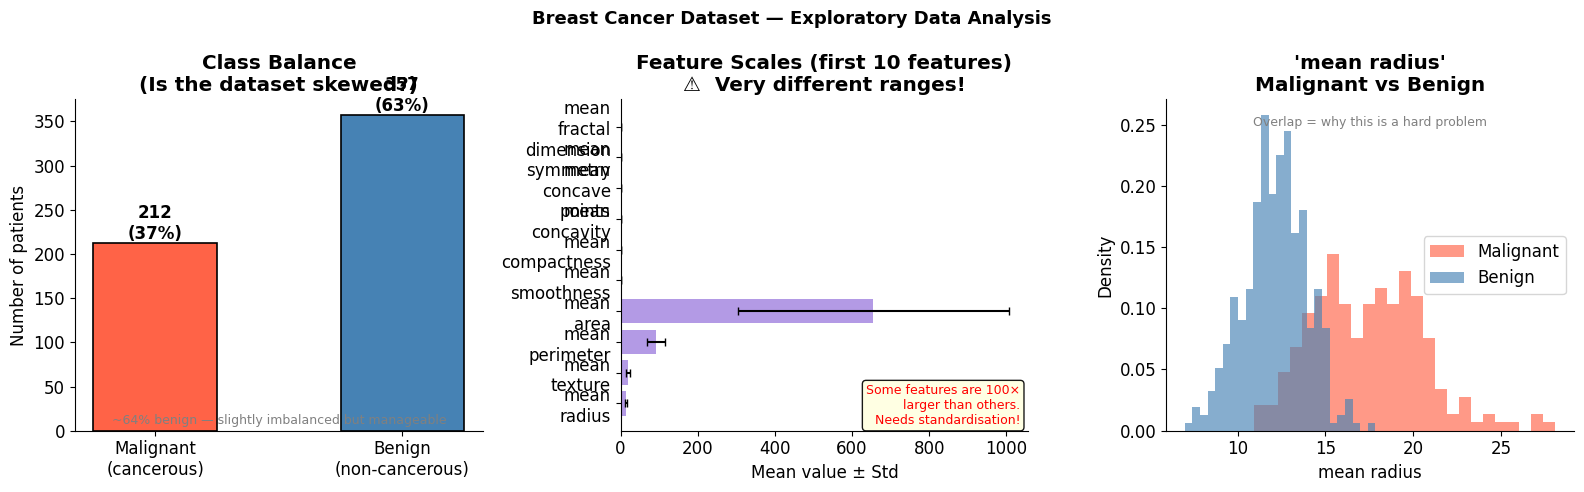

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  EDA PICTURE 1: Class balance + Feature scale problem
# ══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Plot 1: Class balance ─────────────────────────────────────
ax = axes[0]
class_counts = [np.sum(y_raw==0), np.sum(y_raw==1)]
bars = ax.bar(['Malignant\n(cancerous)', 'Benign\n(non-cancerous)'],
              class_counts, color=['tomato','steelblue'], width=0.5,
              edgecolor='black', linewidth=1.2)
ax.set_title("Class Balance\n(Is the dataset skewed?)", fontweight='bold')
ax.set_ylabel("Number of patients")
for bar, cnt in zip(bars, class_counts):
    pct = cnt/len(y_raw)*100
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
            f'{cnt}\n({pct:.0f}%)', ha='center', fontweight='bold')
ax.text(0.5, 0.02, '~64% benign — slightly imbalanced but manageable',
        transform=ax.transAxes, ha='center', fontsize=9, color='gray')

# ── Plot 2: Feature scale problem ─────────────────────────────
ax2 = axes[1]
feature_means = X_raw.mean(axis=0)[:10]
feature_stds  = X_raw.std(axis=0)[:10]
feat_labels   = [n.replace(' ','\n') for n in names[:10]]
ax2.barh(feat_labels, feature_means, xerr=feature_stds,
         color='mediumpurple', alpha=0.7, capsize=3)
ax2.set_title("Feature Scales (first 10 features)\n⚠️  Very different ranges!", fontweight='bold')
ax2.set_xlabel("Mean value ± Std")
ax2.text(0.98, 0.02,
    '''Some features are 100×\nlarger than others.\nNeeds standardisation!''',
    transform=ax2.transAxes, ha='right', fontsize=9,
    color='red', bbox=dict(boxstyle='round',facecolor='lightyellow',alpha=0.9))

# ── Plot 3: Malignant vs Benign distributions ─────────────────
ax3 = axes[2]
feat_idx = 0   # 'mean radius' — most discriminative feature
ax3.hist(X_raw[y_raw==0, feat_idx], bins=25, alpha=0.65,
         color='tomato', label='Malignant', density=True)
ax3.hist(X_raw[y_raw==1, feat_idx], bins=25, alpha=0.65,
         color='steelblue', label='Benign', density=True)
ax3.set_title(f"'{names[feat_idx]}'\nMalignant vs Benign", fontweight='bold')
ax3.set_xlabel(f'{names[feat_idx]}'); ax3.set_ylabel('Density')
ax3.legend()
ax3.text(0.5, 0.92,
    'Overlap = why this is a hard problem',
    transform=ax3.transAxes, ha='center', fontsize=9, color='gray')

plt.suptitle("Breast Cancer Dataset — Exploratory Data Analysis", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

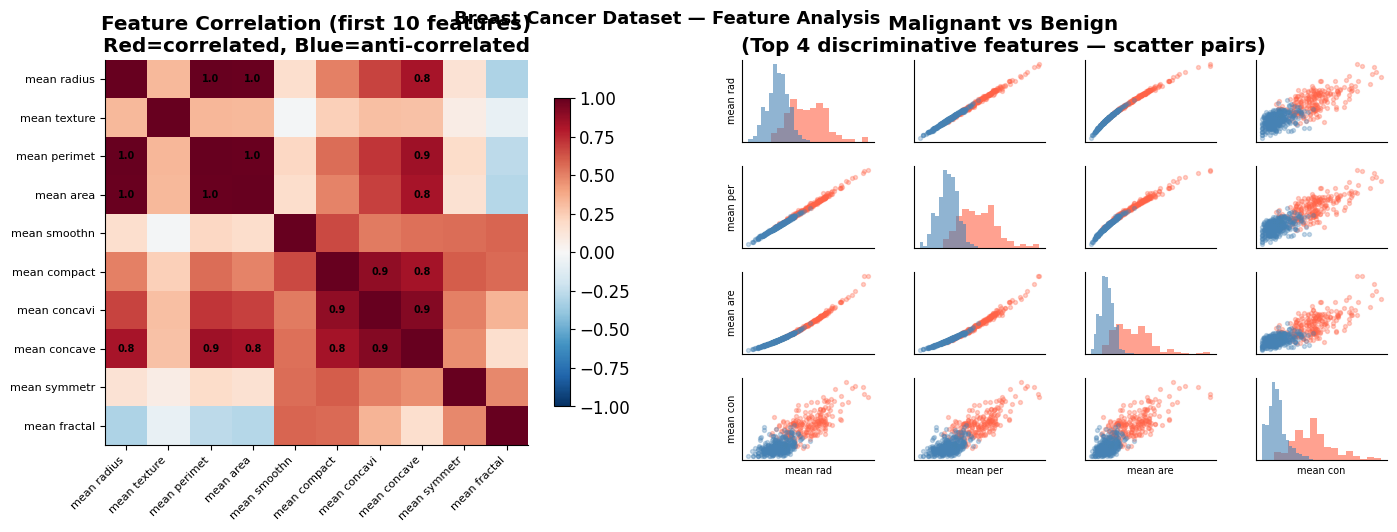


💡 Observations:
  • Features with large separation (sparse overlap) → most useful for classification
  • Highly correlated features carry redundant information
  • Very different feature scales → we MUST standardise before training


In [ ]:
# ══════════════════════════════════════════════════════════════════
#  EDA PICTURE 2: Feature correlation heatmap (top 10 features)
#  + Class separation for top 4 most informative features
# ══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Correlation heatmap ──────────────────────────────────────
ax = axes[0]
feat_subset = X_raw[:, :10]
corr = np.corrcoef(feat_subset.T)
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(10)); ax.set_yticks(range(10))
short_names = [n[:12] for n in names[:10]]
ax.set_xticklabels(short_names, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(short_names, fontsize=8)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Feature Correlation (first 10 features)\nRed=correlated, Blue=anti-correlated",
             fontweight='bold')
# Annotate high correlations
for i in range(10):
    for j in range(10):
        v = corr[i,j]
        if abs(v) > 0.8 and i != j:
            ax.text(j, i, f'{v:.1f}', ha='center', va='center',
                    fontsize=7, color='black', fontweight='bold')

# ── Scatter matrix: top 4 discriminative features ─────────────
ax2 = axes[1]
top4_idx = [0, 2, 3, 7]   # radius, perimeter, area, concavity
top4_names = [names[i] for i in top4_idx]
n = 4
big_ax = ax2
big_ax.axis('off')
big_ax.set_title("Malignant vs Benign\n(Top 4 discriminative features — scatter pairs)",
                  fontweight='bold')

gs_inner = fig.add_gridspec(n, n, left=0.55, right=0.98,
                             bottom=0.08, top=0.88, hspace=0.3, wspace=0.3)
c_map = {0:'tomato', 1:'steelblue'}
for r in range(n):
    for c in range(n):
        ax_ = fig.add_subplot(gs_inner[r,c])
        fi, fj = top4_idx[r], top4_idx[c]
        if r == c:
            for cls in [0,1]:
                ax_.hist(X_raw[y_raw==cls, fi], bins=15, alpha=0.6,
                         color=c_map[cls], density=True)
        else:
            for cls in [0,1]:
                ax_.scatter(X_raw[y_raw==cls, fj], X_raw[y_raw==cls, fi],
                            alpha=0.3, s=8, color=c_map[cls])
        ax_.set_xticks([]); ax_.set_yticks([])
        if r == n-1: ax_.set_xlabel(top4_names[c][:8], fontsize=7)
        if c == 0:   ax_.set_ylabel(top4_names[r][:8], fontsize=7)

plt.suptitle("Breast Cancer Dataset — Feature Analysis", fontsize=13, fontweight='bold')
plt.show()
print("\n💡 Observations:")
print("  • Features with large separation (sparse overlap) → most useful for classification")
print("  • Highly correlated features carry redundant information")
print("  • Very different feature scales → we MUST standardise before training")

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  DATA PREPROCESSING
#
#  Three steps every ML project needs before training:
#  1. Train/test split  — keep some data to evaluate on later
#  2. Standardisation   — make all features have mean=0, std=1
#  3. Shape for numpy   — we use (features, samples) convention
# ══════════════════════════════════════════════════════════════════

# Step 1: Split — 80% training, 20% testing
# WHY? We must evaluate on data the model has NEVER seen.
# Otherwise we're just measuring memorisation, not learning.
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)
# stratify=y_raw ensures same class ratio in both splits

# Step 2: Standardise features
# WHY? From EDA: 'mean radius' ≈ 14,  'mean fractal dimension' ≈ 0.06
# Without scaling, large features dominate — network ignores small ones.
# After scaling: every feature has mean=0, std=1 → equal starting importance.
# IMPORTANT: fit scaler on TRAINING data only, then apply to both.
# Fitting on test data would be cheating (data leakage).
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)   # learn mean/std from train, then transform
X_test  = scaler.transform(X_test)        # apply SAME mean/std to test (no re-fitting!)

# Step 3: Reshape for our network (features × samples)
X_tr = X_train.T          # shape (30, 455)
X_te = X_test.T           # shape (30, 114)
y_tr = y_train.reshape(1,-1).astype(float)   # shape (1, 455)
y_te = y_test.reshape(1,-1).astype(float)    # shape (1, 114)

print("Dataset ready for training:")
print(f"  Training:   {X_tr.shape[1]} patients, {X_tr.shape[0]} features each")
print(f"  Testing:    {X_te.shape[1]} patients, {X_te.shape[0]} features each")
print()
print("  Feature scaling check (after standardisation):")
print(f"    mean radius — mean: {X_tr[0].mean():.3f}, std: {X_tr[0].std():.3f}  (target: 0.0, 1.0)")
print(f"    mean texture— mean: {X_tr[1].mean():.3f}, std: {X_tr[1].std():.3f}")

Dataset ready for training:
  Training:   455 patients, 30 features each
  Testing:    114 patients, 30 features each

  Feature scaling check (after standardisation):
    mean radius — mean: -0.000, std: 1.000  (target: 0.0, 1.0)
    mean texture— mean: 0.000, std: 1.000


---
## ⏱ 0:30 – 1:00 | Section 7: Better Optimisers

### 🧩 The Problem with Vanilla SGD

Vanilla SGD updates weights with one simple rule:
$$W \leftarrow W - \alpha \cdot \nabla L$$

Three things go wrong:

**Problem 1 — Learning rate is fragile:**  
Too large = overshoots the minimum and bounces around.  
Too small = takes thousands of extra steps.  
The "right" value is different for every problem.

**Problem 2 — One learning rate for ALL weights:**  
Some weights need large updates (they're barely moving the loss).  
Others need tiny updates (they're already near optimal).  
A single global $\alpha$ can't serve both.

**Problem 3 — Saddle points:**  
In high dimensions, gradient = 0 at many points that are NOT minima.  
SGD gets stuck there.

---

### The Optimiser Family Tree

Each one adds one idea to fix one problem:

```
SGD → (+momentum) → SGD+Momentum → (+adaptive lr) → Adam
```

---

### Momentum — *"Remember where you were going"*
$$v_t = \beta v_{t-1} + (1-\beta)\nabla L, \qquad W \leftarrow W - \alpha v_t$$
$\beta = 0.9$: keep 90% of old velocity + 10% new gradient.

Like a ball rolling downhill — it builds up speed in consistent directions and resists random bumps.

---

### Adam — *"Adaptive + Momentum"* (the default choice)
Combines momentum AND per-parameter learning rate:

$$m_t = \beta_1 m_{t-1} + (1-\beta_1)\nabla L \quad \text{(velocity, like momentum)}$$
$$v_t = \beta_2 v_{t-1} + (1-\beta_2)(\nabla L)^2 \quad \text{(gradient size history)}$$
$$W \leftarrow W - \frac{\alpha}{\sqrt{v_t}+\epsilon} \cdot m_t$$

**Dividing by $\sqrt{v_t}$:**  if a weight's gradient has been consistently large (it moves easily), shrink its learning rate. If a weight's gradient has been small (it's stuck), boost its learning rate.

> 🏆 **Default settings:** $\alpha=0.001$, $\beta_1=0.9$, $\beta_2=0.999$, $\epsilon=10^{-8}$  
> These almost never need changing. Start here for any new problem.

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  OPTIMISER IMPLEMENTATIONS
#  Each one is short. Focus on the comments explaining WHY.
# ══════════════════════════════════════════════════════════════════

class SGD_plain:
    """Vanilla SGD: W = W - lr * gradient. Simple but fragile."""
    def __init__(self, lr=0.1):
        self.lr = lr

    def update(self, params, grads):
        for l in range(1, len(params)//2+1):
            params[f'W{l}'] -= self.lr * grads[f'dW{l}']
            params[f'b{l}'] -= self.lr * grads[f'db{l}']


class SGD_Momentum:
    """
    SGD + Momentum — builds velocity over time.

    WHY it helps:
    • In directions where gradient is consistently the same sign,
      velocity builds up → faster progress.
    • In directions where gradient oscillates (up/down/up/down),
      velocities cancel out → less bouncing.

    beta=0.9: standard value. Higher = more memory, slower to change direction.
    """
    def __init__(self, lr=0.01, beta=0.9):
        self.lr   = lr
        self.beta = beta
        self.v    = {}   # velocity for each parameter

    def update(self, params, grads):
        for l in range(1, len(params)//2+1):
            for p in ['W','b']:
                key = f'{p}{l}'
                if key not in self.v:
                    self.v[key] = np.zeros_like(params[key])
                # old velocity (momentum) + new gradient signal
                self.v[key] = self.beta*self.v[key] + (1-self.beta)*grads[f'd{key}']
                params[key] -= self.lr * self.v[key]


class Adam:
    """
    Adam — the default optimiser for most deep learning.

    Combines two ideas:
    1. Momentum (m): smooth out gradient direction
    2. Adaptive lr (v): large-gradient params get smaller lr, small-gradient params get larger lr

    Bias correction: at step 1, m and v are initialised at 0.
    Without correction, they're far too small in early steps.
    Dividing by (1 - beta^t) rescales them to true gradient magnitude.

    WHY choose Adam over SGD?
    → Much less sensitive to learning rate choice
    → Works well on a huge variety of problems out of the box
    → Start with Adam; only switch if you have a specific reason
    """
    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr    = lr
        self.beta1 = beta1    # momentum decay (how long to remember direction)
        self.beta2 = beta2    # gradient-scale decay (how long to remember magnitude)
        self.eps   = eps      # prevents division by zero
        self.m     = {}       # first moment  (velocity)
        self.v     = {}       # second moment (squared gradient — tracks magnitude)
        self.t     = 0        # step counter for bias correction

    def update(self, params, grads):
        self.t += 1
        for l in range(1, len(params)//2+1):
            for p in ['W','b']:
                key  = f'{p}{l}'
                gkey = f'd{key}'
                if key not in self.m:
                    self.m[key] = np.zeros_like(params[key])
                    self.v[key] = np.zeros_like(params[key])
                g = grads[gkey]
                self.m[key] = self.beta1*self.m[key] + (1-self.beta1)*g
                self.v[key] = self.beta2*self.v[key] + (1-self.beta2)*g**2
                # Bias-corrected estimates
                m_hat = self.m[key] / (1-self.beta1**self.t)
                v_hat = self.v[key] / (1-self.beta2**self.t)
                params[key] -= self.lr * m_hat / (np.sqrt(v_hat)+self.eps)

print("✅  Three optimisers ready!")
print()
print(f"  {'Optimiser':<16} {'Adaptive LR?':<16} {'Momentum?':<12} {'When to use'}")
print("  " + "─"*60)
print(f"  {'SGD':<16} {'No':<16} {'No':<12} Simple tests / baselines")
print(f"  {'SGD+Momentum':<16} {'No':<16} {'Yes ✓':<12} If you need full control")
print(f"  {'Adam':<16} {'Yes ✓':<16} {'Yes ✓':<12} DEFAULT — start here always")

✅  Three optimisers ready!

  Optimiser        Adaptive LR?     Momentum?    When to use
  ────────────────────────────────────────────────────────────
  SGD              No               No           Simple tests / baselines
  SGD+Momentum     No               Yes ✓        If you need full control
  Adam             Yes ✓            Yes ✓        DEFAULT — start here always


---
## ⏱ 1:00 – 1:30 | Section 8: Weight Initialisation

### 🧩 Why Does It Matter?

Before training starts, we must set initial values for every weight.
A bad choice can completely prevent training — no optimiser can save you.

---

### ❌ All Zeros — Never Use This

All weights = 0 → every neuron computes $W \cdot x = 0$.  
Every neuron is identical → every gradient is identical → every update is identical.  
No matter how long you train: the network has effectively **one neuron**.

---

### ⚠️ Small Random — Works, but Not Always

$W \sim \mathcal{N}(0,\ 0.01)$

- Breaks the symmetry problem ✅
- But activations slowly **shrink** through 10+ layers → eventually near zero → **vanishing gradients** ❌

---

### ✅ Xavier Init — for Tanh/Sigmoid layers

$$W \sim \mathcal{N}\!\left(0,\ \sqrt{\frac{1}{n_{\text{in}}}}\right)$$

**The goal:** keep the *variance* of activations roughly constant across all layers.  
This formula is derived mathematically so variance in = variance out, for tanh.

---

### ✅ He Init — for ReLU layers

$$W \sim \mathcal{N}\!\left(0,\ \sqrt{\frac{2}{n_{\text{in}}}}\right)$$

**Why the extra ×2?** ReLU zeros out ~half of all activations (the negative half).  
This halves the variance. We double it back by using $\frac{2}{n}$ instead of $\frac{1}{n}$.

> 🏆 **Simple rule:** Using ReLU? → **He init**. Using Tanh/Sigmoid? → **Xavier init**.

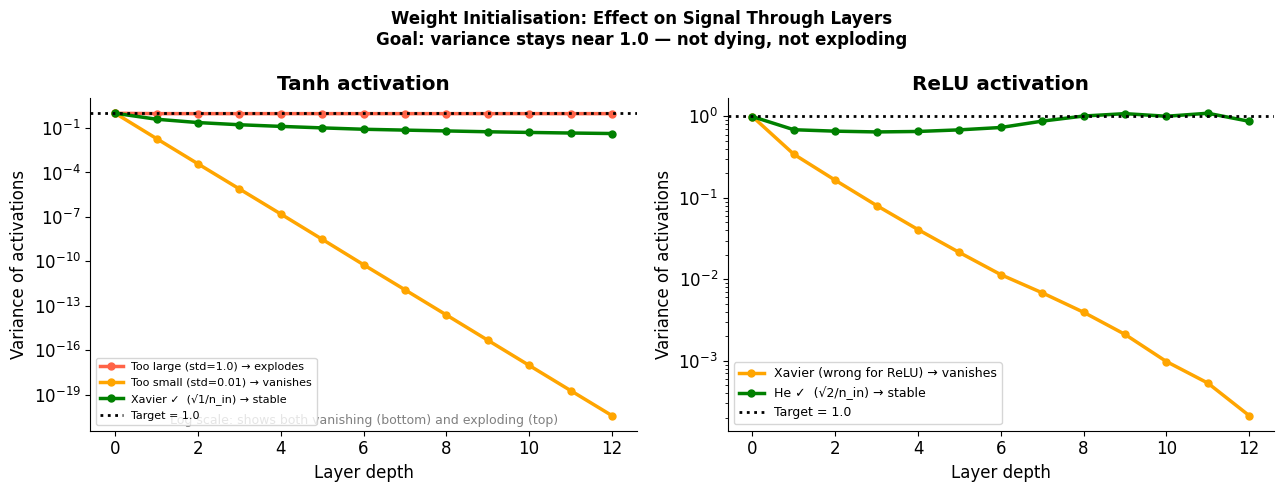


📌  With CORRECT init: signal stays stable across 12 layers.
    With WRONG init:    signal dies by layer 4–6.

    Rule of thumb:
    → ReLU layers  :  He init    std = √(2 / n_in)
    → Tanh/Sigmoid :  Xavier init  std = √(1 / n_in)


In [ ]:
# ══════════════════════════════════════════════════════════════════
#  PICTURE: Watch signal variance explode/vanish/stay stable
#  through 12 layers under different initialisation strategies.
#
#  If variance → 0:  gradients die → vanishing gradient problem
#  If variance → ∞:  activations overflow → exploding gradient
#  If variance ≈ 1:  stable training all the way down ✓
# ══════════════════════════════════════════════════════════════════

def trace_variance(n_layers=12, n_neurons=200, init_std=1.0, act_fn=relu):
    """
    Pass 1000 random inputs through 'n_layers' random weight layers.
    Record the variance of the activation at each layer.
    We want this to stay near 1.0 throughout.
    """
    np.random.seed(0)
    x = np.random.randn(n_neurons, 1000)
    variances = [float(np.var(x))]
    for _ in range(n_layers):
        W = np.random.randn(n_neurons, n_neurons) * init_std
        x = act_fn(W @ x)
        variances.append(float(np.var(x)))
    return variances

N = 200   # neurons per layer

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("""Weight Initialisation: Effect on Signal Through Layers
Goal: variance stays near 1.0 — not dying, not exploding""",
             fontsize=12, fontweight='bold')

# ── Tanh + Xavier ──────────────────────────────────────────────
tanh_configs = [
    (1.0,               "Too large (std=1.0) → explodes", 'tomato'),
    (0.01,              "Too small (std=0.01) → vanishes", 'orange'),
    (np.sqrt(1.0/N),    "Xavier ✓  (√1/n_in) → stable",   'green'),
]
for std, lbl, c in tanh_configs:
    v = trace_variance(init_std=std, act_fn=np.tanh)
    ax1.plot(v, lw=2.5, marker='o', ms=5, label=lbl, color=c)
ax1.axhline(1.0, color='black', ls=':', lw=2, label='Target = 1.0')
ax1.set_yscale('log'); ax1.set_title('Tanh activation', fontweight='bold')
ax1.set_xlabel('Layer depth'); ax1.set_ylabel('Variance of activations')
ax1.legend(fontsize=8)
ax1.text(0.5, 0.02, 'Log scale: shows both vanishing (bottom) and exploding (top)',
        transform=ax1.transAxes, ha='center', fontsize=9, color='gray')

# ── ReLU + He ──────────────────────────────────────────────────
relu_configs = [
    (np.sqrt(1.0/N),  "Xavier (wrong for ReLU) → vanishes", 'orange'),
    (np.sqrt(2.0/N),  "He ✓  (√2/n_in) → stable",           'green'),
]
for std, lbl, c in relu_configs:
    v = trace_variance(init_std=std, act_fn=relu)
    ax2.plot(v, lw=2.5, marker='o', ms=5, label=lbl, color=c)
ax2.axhline(1.0, color='black', ls=':', lw=2, label='Target = 1.0')
ax2.set_yscale('log'); ax2.set_title('ReLU activation', fontweight='bold')
ax2.set_xlabel('Layer depth'); ax2.set_ylabel('Variance of activations')
ax2.legend(fontsize=9)

plt.tight_layout(); plt.show()

print("\n📌  With CORRECT init: signal stays stable across 12 layers.")
print("    With WRONG init:    signal dies by layer 4–6.")
print()
print("    Rule of thumb:")
print("    → ReLU layers  :  He init    std = √(2 / n_in)")
print("    → Tanh/Sigmoid :  Xavier init  std = √(1 / n_in)")


---
## ⏱ 1:45 – 2:15 | Section 9: Regularisation *(after break)*

### 🧩 The Overfitting Problem — A Story

Imagine a student who memorises every question from past exams word-for-word.
On the same exam: 100%.
On a new exam with slightly different wording: 30%.

They memorised the **noise** (specific wording) instead of learning the **signal** (concepts).

A neural network does the same thing if we let it.
It will memorise every training sample — including noise and outliers.
Result: near-perfect training accuracy, terrible test accuracy.

---

### Solution 1: L2 Regularisation (Weight Decay)

Add a penalty to the loss that punishes large weights:
$$L_{\text{total}} = L_{\text{original}} + \frac{\lambda}{2m}\sum\|W\|^2$$

**Why does this help?**  
Large weights = sharp, overconfident decisions = memorising noise.  
Forcing weights to stay small = smoother, more general decisions.

Each update becomes: $W \leftarrow W\left(1 - \frac{\alpha\lambda}{m}\right) - \alpha\nabla L$  
— weights *decay* toward zero every step.

---

### Solution 2: Dropout

**During training:** randomly silence a fraction $p$ of neurons each step.

**Why?**  
Neurons can't rely on each other ("if I get this wrong, neuron 47 will save me").  
Each neuron must be independently useful.  
Forces more robust, general representations.

**At test time:** turn dropout off. Use all neurons.  
*(We scale activations during training — called inverted dropout — so no change needed at test time.)*

> 🔑 **Typical values:** Dropout rate = 0.2 to 0.5. L2 lambda = 0.001 to 0.01.

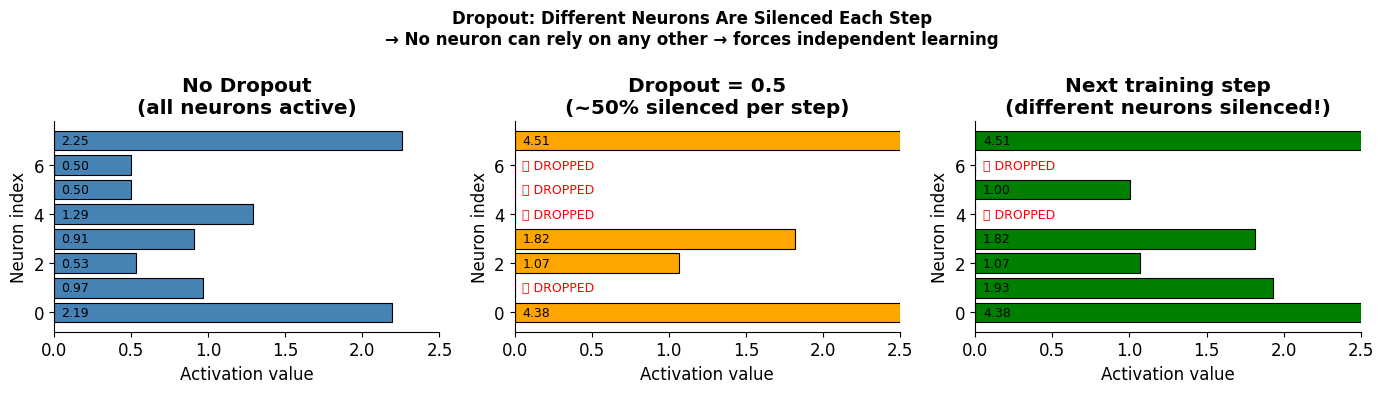


💡  Key insight: because the silenced neurons change EVERY step,
    the network can never rely on co-adaptation between specific neurons.
    Every neuron must learn to be useful on its own.


In [ ]:
# ══════════════════════════════════════════════════════════════════
#  DROPOUT — implementation
# ══════════════════════════════════════════════════════════════════

def dropout(A, rate, training=True):
    """
    Randomly zero out neurons during training.

    rate: fraction to DROP (e.g. rate=0.3 means 30% of neurons zeroed)
    training=True: apply dropout (training mode)
    training=False: no dropout (inference/test mode)

    WHY inverted dropout (dividing by 1-rate)?
    During training: only (1-rate) fraction of neurons are active.
    If we scale up by 1/(1-rate), the expected output magnitude stays
    the same as if no dropout were applied.
    This means NO code change is needed at test time.
    """
    if not training:
        return A, None
    mask = (np.random.rand(*A.shape) > rate).astype(float)
    return A * mask / (1-rate), mask


# ══════════════════════════════════════════════════════════════════
#  PICTURE: Show what dropout actually does to a layer
# ══════════════════════════════════════════════════════════════════

np.random.seed(7)
A_demo = np.abs(np.random.randn(8, 1)) + 0.5   # 8 neurons, simulated activations

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax_i, (rate, title, c) in enumerate([
    (0.0, '''No Dropout
(all neurons active)''', 'steelblue'),
    (0.5, '''Dropout = 0.5
(~50% silenced per step)''', 'orange'),
    (0.5, '''Next training step
(different neurons silenced!)''', 'green'),
]):
    np.random.seed(ax_i * 10)
    A_show, _ = dropout(A_demo, rate=rate, training=(rate>0))
    ax = axes[ax_i]
    colors_ = ['tomato' if v < 0.05 else c for v in A_show.flatten()]
    bars = ax.barh(range(8), A_show.flatten(), color=colors_,
                   edgecolor='black', linewidth=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Activation value')
    ax.set_ylabel('Neuron index')
    ax.set_xlim(0, 2.5)
    for j, v in enumerate(A_show.flatten()):
        label = '💀 DROPPED' if v < 0.05 else f'{v:.2f}'
        ax.text(0.05, j, label, va='center', fontsize=9,
                color='red' if v < 0.05 else 'black')

plt.suptitle("""Dropout: Different Neurons Are Silenced Each Step
→ No neuron can rely on any other → forces independent learning""",
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print("\n💡  Key insight: because the silenced neurons change EVERY step,")
print("    the network can never rely on co-adaptation between specific neurons.")
print("    Every neuron must learn to be useful on its own.")

---
## ⏱ 2:15 – 2:45 | Section 10: Batch Normalisation

### 🧩 The Problem — Moving Goalposts

As we train, Layer 1's weights change.
This changes the *distribution* of Layer 1's outputs.
But Layer 2's weights were tuned for the *old* distribution.
So Layer 2 now has to re-adjust for the new distribution — while also trying to learn its own task.

This is like trying to learn a new skill while someone keeps changing the rules.  
It slows training and causes instability. This is called **internal covariate shift**.

---

### The Fix: Normalise Each Layer's Inputs

For each mini-batch, normalise the pre-activation $Z$:

$$\hat{z} = \frac{z - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$$

Then apply learnable scale ($\gamma$) and shift ($\beta$):
$$\text{BN}(z) = \gamma\hat{z} + \beta$$

---

### Why $\gamma$ and $\beta$?

Pure normalisation forces every layer to always have mean=0, std=1.
But the network might need a different distribution for a particular layer.
$\gamma$ and $\beta$ are *learnable* — the network decides whether to keep the normalised form or restore a different distribution.

If the normalised form is unhelpful, the network sets $\gamma = \sigma_B$, $\beta = \mu_B$, and BatchNorm becomes identity.
So **BatchNorm can never hurt** — it can only help.

---

### Benefits
| Benefit | Why |
|---|---|
| Faster training | Stable distributions → consistent gradients |
| Less sensitive to init | Even bad initial weights get normalised fast |
| Mild regularisation | Batch statistics add slight noise → helps generalisation |
| Allows higher learning rate | Less risk of exploding with stable activations |

> 📌 **Where to place it:** Linear layer → **BatchNorm** → Activation

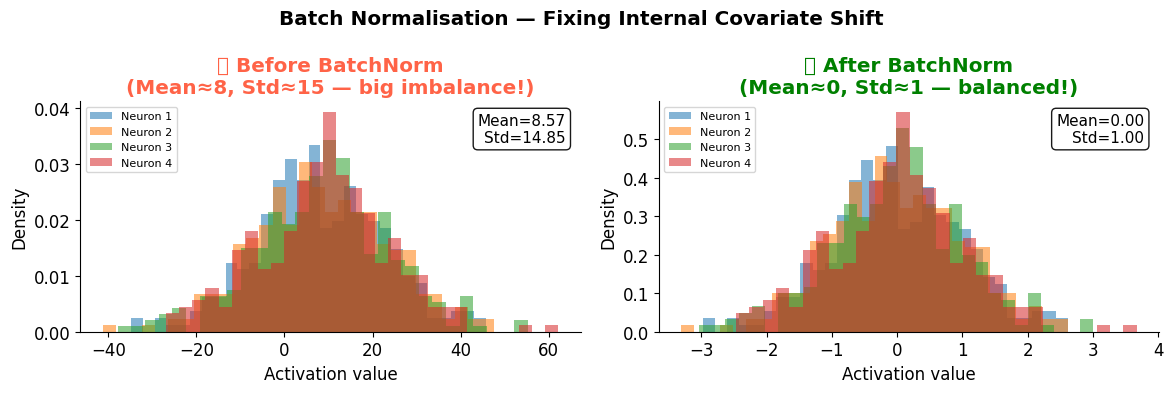

  Before: mean=8.57,  std=14.85
  After:  mean=0.0000, std=1.0000

  This happens at EVERY layer, EVERY batch.
  Result: the next layer always sees a clean, consistent distribution.


In [ ]:
# ══════════════════════════════════════════════════════════════════
#  BATCH NORMALISATION — clean implementation
# ══════════════════════════════════════════════════════════════════

class BatchNorm:
    """
    Normalise layer inputs to mean=0, std=1 per mini-batch,
    then apply learnable scale (gamma) and shift (beta).

    WHY learnable gamma and beta?
    Without them, we'd always force mean=0 std=1.
    Some layers might need a different distribution.
    Gamma and beta give the network freedom to undo the normalisation
    if that's actually better — so BatchNorm can never be harmful.

    At TRAINING time: use current batch's mean and variance.
    At TEST time:     use running averages accumulated during training
                      (single samples don't have a batch to normalise with).
    """
    def __init__(self, n_features, eps=1e-8, momentum=0.9):
        self.eps      = eps
        self.momentum = momentum
        self.gamma = np.ones((n_features, 1))    # learnable scale, start=1
        self.beta  = np.zeros((n_features, 1))   # learnable shift, start=0
        # Running stats for test time
        self.run_mean = np.zeros((n_features, 1))
        self.run_var  = np.ones((n_features, 1))

    def forward(self, Z, training=True):
        if training:
            mu    = Z.mean(axis=1, keepdims=True)
            var   = Z.var(axis=1,  keepdims=True)
            Z_hat = (Z - mu) / np.sqrt(var + self.eps)
            out   = self.gamma * Z_hat + self.beta
            # Update running stats
            self.run_mean = self.momentum*self.run_mean + (1-self.momentum)*mu
            self.run_var  = self.momentum*self.run_var  + (1-self.momentum)*var
        else:
            Z_hat = (Z - self.run_mean) / np.sqrt(self.run_var + self.eps)
            out   = self.gamma * Z_hat + self.beta
        return out


# ══════════════════════════════════════════════════════════════════
#  PICTURE: Show what BatchNorm does to a badly-scaled layer
# ══════════════════════════════════════════════════════════════════

np.random.seed(5)
bn = BatchNorm(n_features=4)
Z_bad    = np.random.randn(4, 300) * 15 + 8   # badly scaled: mean≈8, std≈15
Z_normed = bn.forward(Z_bad, training=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, (data, title, c) in enumerate([
    (Z_bad,   '''❌ Before BatchNorm
(Mean≈8, Std≈15 — big imbalance!)''', 'tomato'),
    (Z_normed,'''✅ After BatchNorm
(Mean≈0, Std≈1 — balanced!)''',        'green')
]):
    ax = axes[i]
    for n in range(4):
        ax.hist(data[n], bins=30, alpha=0.55, label=f'Neuron {n+1}', density=True)
    m, s = data.mean(), data.std()
    ax.set_title(title, fontweight='bold', color=c)
    ax.set_xlabel('Activation value'); ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.text(0.97, 0.95, f'Mean={m:.2f}\nStd={s:.2f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=11,
            bbox=dict(boxstyle='round',facecolor='white',alpha=0.9))

plt.suptitle("Batch Normalisation — Fixing Internal Covariate Shift", fontweight='bold')
plt.tight_layout(); plt.show()

print(f"  Before: mean={Z_bad.mean():.2f},  std={Z_bad.std():.2f}")
print(f"  After:  mean={Z_normed.mean():.4f}, std={Z_normed.std():.4f}")
print()
print("  This happens at EVERY layer, EVERY batch.")
print("  Result: the next layer always sees a clean, consistent distribution.")


---
## ⏱ 2:45 – 3:00 | Final Demo: Everything on the Breast Cancer Dataset

Let's build **two networks** on the breast cancer data and compare them:

| Network | What it uses |
|---|---|
| 🔵 Naive | Small random init, SGD, no regularisation |
| 🟢 Best Practices | He init, Adam, L2 regularisation, Dropout |

Both have the same architecture. Same data. Only training strategy differs.

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  BEST PRACTICES NETWORK — all Day 2 techniques together
#  Extends SimpleNeuralNet with: He init, Adam, L2, Dropout
# ══════════════════════════════════════════════════════════════════

class BestPracticesNet:
    """
    A neural network with all Day 2 improvements:
      • He init      — correct variance for ReLU, stable signal flow
      • Adam         — adaptive, momentum-based, robust to lr choice
      • L2 penalty   — prevents weights from growing huge / overfitting
      • Dropout      — prevents neurons from co-adapting
    """
    def __init__(self, layer_sizes, lr=0.001, lambd=0.005, drop_rate=0.2):
        self.sizes     = layer_sizes
        self.L         = len(layer_sizes)-1
        self.lambd     = lambd      # L2 strength
        self.drop_rate = drop_rate  # fraction of neurons to drop
        self.params    = {}
        self.cache     = {}
        self.masks     = {}
        self.train_loss = []
        self.test_loss  = []
        self.adam       = Adam(lr=lr)
        self._he_init()

    def _he_init(self):
        """
        He init: std = sqrt(2/n_in).
        The 2 compensates for ReLU zeroing ~50% of activations.
        Without it, variance halves every layer → signal vanishes.
        """
        np.random.seed(42)
        for l in range(1, self.L+1):
            n_in  = self.sizes[l-1]
            n_out = self.sizes[l]
            self.params[f'W{l}'] = np.random.randn(n_out, n_in) * np.sqrt(2.0/n_in)
            self.params[f'b{l}'] = np.zeros((n_out, 1))

    def forward(self, X, training=True):
        self.masks = {}
        self.cache = {'A0': X}
        A = X
        for l in range(1, self.L):
            Z = self.params[f'W{l}'] @ A + self.params[f'b{l}']
            A = relu(Z)
            if training:   # Dropout only during training, not at test time
                A, mask = dropout(A, rate=self.drop_rate, training=True)
                self.masks[l] = mask
            self.cache[f'Z{l}'] = Z
            self.cache[f'A{l}'] = A
        Z = self.params[f'W{self.L}'] @ A + self.params[f'b{self.L}']
        A = sigmoid(Z)
        self.cache[f'Z{self.L}'] = Z
        self.cache[f'A{self.L}'] = A
        return A

    def compute_loss(self, yp, yt):
        bce = binary_cross_entropy(yp.flatten(), yt.flatten())
        l2  = (self.lambd/2) * sum(np.sum(self.params[f'W{l}']**2)
                                   for l in range(1,self.L+1))
        return bce + l2

    def backward(self, y):
        m     = y.shape[1]
        grads = {}
        delta = self.cache[f'A{self.L}'] - y
        for l in range(self.L, 0, -1):
            A_prev = self.cache[f'A{l-1}']
            # L2 gradient term added to normal weight gradient
            grads[f'dW{l}'] = (1/m)*delta@A_prev.T + (self.lambd/m)*self.params[f'W{l}']
            grads[f'db{l}'] = (1/m)*np.sum(delta, axis=1, keepdims=True)
            if l > 1:
                delta = (self.params[f'W{l}'].T @ delta) * relu_grad(self.cache[f'Z{l-1}'])
                if (l-1) in self.masks:
                    delta = delta * self.masks[l-1] / (1-self.drop_rate)
        return grads

    def train(self, X_tr, y_tr, X_te, y_te, epochs=800, print_every=200):
        for epoch in range(epochs):
            yp_tr = self.forward(X_tr, training=True)
            loss  = self.compute_loss(yp_tr, y_tr)
            self.train_loss.append(loss)

            # Evaluate on test set (this will overwrite self.cache)
            yp_te = self.forward(X_te, training=False)
            self.test_loss.append(binary_cross_entropy(yp_te.flatten(), y_te.flatten()))

            # IMPORTANT: Re-run forward pass with training data to ensure cache is correct for backward pass
            _ = self.forward(X_tr, training=True)

            grads = self.backward(y_tr)
            self.adam.update(self.params, grads)
            if epoch % print_every == 0:
                # Use the yp_tr and yp_te already computed for this epoch
                tr_acc = (yp_tr.round()==y_tr).mean()*100
                te_acc = (yp_te.round()==y_te).mean()*100
                print(f"  Epoch {epoch:>4} | Train loss: {loss:.4f}  "
                      f"Train acc: {tr_acc:.1f}%   Test acc: {te_acc:.1f}%")


In [ ]:
# ══════════════════════════════════════════════════════════════════
#  TRAIN BOTH NETWORKS ON BREAST CANCER DATA
# ══════════════════════════════════════════════════════════════════

print("═"*60)
print("  🔵  NAIVE NETWORK  (Day 1 style)")
print("═"*60)
naive_net = SimpleNeuralNet(layer_sizes=[30, 16, 8, 1], lr=0.05)
naive_train_loss, naive_test_loss = [], []

for epoch in range(801):
    # Perform forward pass for training data to get predictions and populate cache
    yp_tr_for_loss = naive_net.forward(X_tr)
    naive_train_loss.append(binary_cross_entropy(yp_tr_for_loss.flatten(), y_tr.flatten()))

    # Perform forward pass for test data for evaluation. This will overwrite the cache.
    # We need to explicitly re-populate the cache with training data before backward.
    yp_te_for_loss = naive_net.forward(X_te)
    naive_test_loss.append(binary_cross_entropy(yp_te_for_loss.flatten(), y_te.flatten()))

    # IMPORTANT: Re-run forward pass with training data to ensure cache is correct for backward pass
    _ = naive_net.forward(X_tr)

    grads = naive_net.backward(y_tr)
    naive_net.update(grads)
    if epoch % 200 == 0:
        # Re-calculate accuracies for printing, which will again update the cache.
        # This is acceptable as it's for display and not directly impacting the training step's backward.
        tr_acc = (naive_net.forward(X_tr).round()==y_tr).mean()*100
        te_acc = (naive_net.forward(X_te).round()==y_te).mean()*100
        print(f"  Epoch {epoch:>4} | Train acc: {tr_acc:.1f}%   Test acc: {te_acc:.1f}%")

print()
print("═"*60)
print("  🟢  BEST PRACTICES NETWORK  (Day 2 style)")
print("═"*60)
best_net = BestPracticesNet(layer_sizes=[30, 16, 8, 1], lr=0.001, lambd=0.005, drop_rate=0.2)
best_net.train(X_tr, y_tr, X_te, y_te, epochs=801, print_every=200)

════════════════════════════════════════════════════════════
  🔵  NAIVE NETWORK  (Day 1 style)
════════════════════════════════════════════════════════════
  Epoch    0 | Train acc: 62.6%   Test acc: 63.2%
  Epoch  200 | Train acc: 62.6%   Test acc: 63.2%
  Epoch  400 | Train acc: 62.6%   Test acc: 63.2%
  Epoch  600 | Train acc: 62.6%   Test acc: 63.2%
  Epoch  800 | Train acc: 62.6%   Test acc: 63.2%

════════════════════════════════════════════════════════════
  🟢  BEST PRACTICES NETWORK  (Day 2 style)
════════════════════════════════════════════════════════════
  Epoch    0 | Train loss: 1.2001  Train acc: 34.9%   Test acc: 31.6%
  Epoch  200 | Train loss: 0.2536  Train acc: 96.9%   Test acc: 95.6%
  Epoch  400 | Train loss: 0.2087  Train acc: 98.7%   Test acc: 98.2%
  Epoch  600 | Train loss: 0.1813  Train acc: 99.3%   Test acc: 96.5%
  Epoch  800 | Train loss: 0.1850  Train acc: 98.5%   Test acc: 96.5%


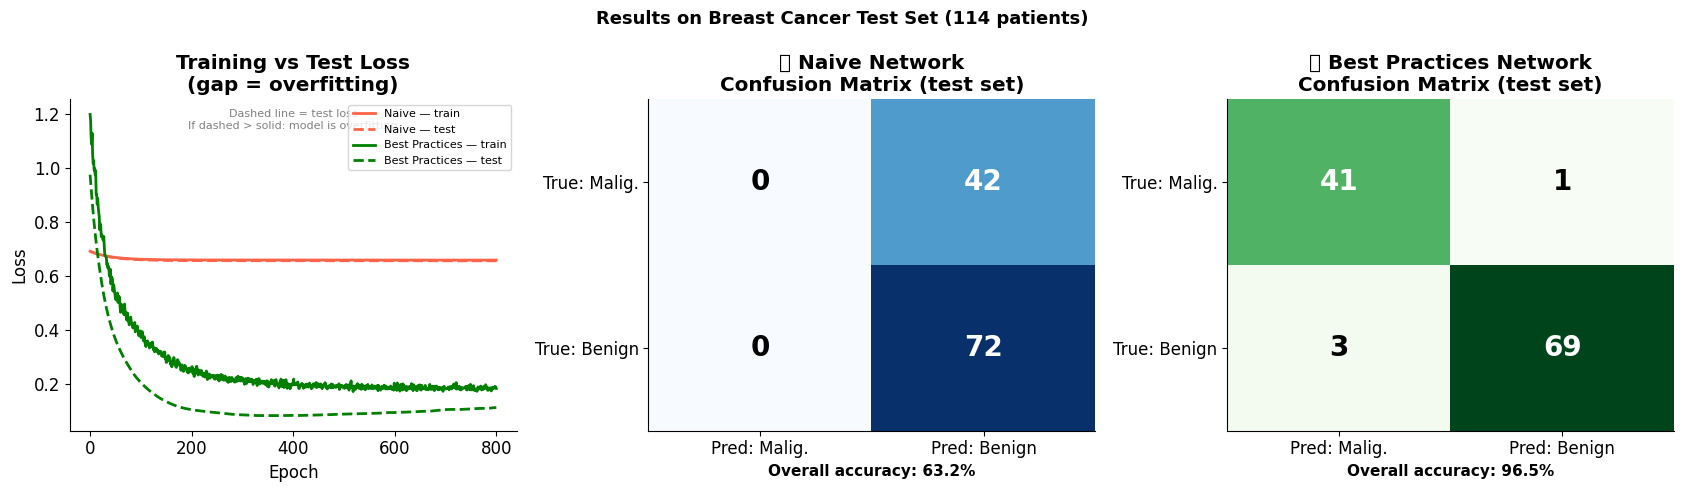


Detailed Test Report — Best Practices Network:
              precision    recall  f1-score   support

   Malignant       0.93      0.98      0.95        42
      Benign       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114


🔴  In a real clinical tool, 'False Negatives' (missed cancers) matter most.
    The network should be calibrated to minimise those even at the cost of
    more 'False Positives' (healthy patients flagged for further testing).


In [ ]:
# ══════════════════════════════════════════════════════════════════
#  FINAL RESULTS: Loss curves + confusion matrix + classification report
# ══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── Loss curves ─────────────────────────────────────────────────
ax = axes[0]
ax.plot(naive_train_loss, color='tomato',     lw=2, label='Naive — train')
ax.plot(naive_test_loss,  color='tomato',     lw=2, ls='--', label='Naive — test')
ax.plot(best_net.train_loss, color='green',   lw=2, label='Best Practices — train')
ax.plot(best_net.test_loss,  color='green',   lw=2, ls='--', label='Best Practices — test')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Training vs Test Loss\n(gap = overfitting)', fontweight='bold')
ax.legend(fontsize=8)
ax.text(0.5, 0.97,
        'Dashed line = test loss\nIf dashed > solid: model is overfitting',
        transform=ax.transAxes, ha='center', va='top', fontsize=8, color='gray')

# ── Confusion matrices ──────────────────────────────────────────
for ax_i, (net_obj, pred_fn, title, c) in enumerate([
    (naive_net, lambda: naive_net.forward(X_te).round(), '🔵 Naive', 'Blues'),
    (best_net,  lambda: best_net.forward(X_te, training=False).round(), '🟢 Best Practices', 'Greens'),
]):
    preds = pred_fn().flatten().astype(int)
    cm    = confusion_matrix(y_te.flatten().astype(int), preds)
    ax_cm = axes[ax_i+1]
    im = ax_cm.imshow(cm, cmap=c, aspect='auto')
    ax_cm.set_xticks([0,1]); ax_cm.set_yticks([0,1])
    ax_cm.set_xticklabels(['Pred: Malig.','Pred: Benign'])
    ax_cm.set_yticklabels(['True: Malig.','True: Benign'])
    ax_cm.set_title(f'{title} Network\nConfusion Matrix (test set)', fontweight='bold')
    for r in range(2):
        for c_ in range(2):
            ax_cm.text(c_,r, str(cm[r,c_]), ha='center', va='center',
                       fontsize=20, fontweight='bold',
                       color='white' if cm[r,c_] > cm.max()/2 else 'black')
    acc_  = (preds == y_te.flatten().astype(int)).mean()*100
    ax_cm.set_xlabel(f'Overall accuracy: {acc_:.1f}%', fontsize=11, fontweight='bold')

plt.suptitle("Results on Breast Cancer Test Set (114 patients)",
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Text report ──────────────────────────────────────────────────
print("\nDetailed Test Report — Best Practices Network:")
print("=" * 52)
preds_best = best_net.forward(X_te, training=False).round().flatten().astype(int)
print(classification_report(y_te.flatten().astype(int), preds_best,
                             target_names=['Malignant','Benign']))

print("\n🔴  In a real clinical tool, 'False Negatives' (missed cancers) matter most.")
print("    The network should be calibrated to minimise those even at the cost of")
print("    more 'False Positives' (healthy patients flagged for further testing).")

---
## 📋 Complete Cheat Sheet — Everything in One Place

---

### Activation Functions

| Activation | Formula | Use when |
|---|---|---|
| **ReLU** | max(0, z) | Default for hidden layers |
| **Leaky ReLU** | max(0.01z, z) | If neurons are dying (outputting 0 always) |
| **Sigmoid** | 1/(1+e⁻ᶻ) | Output layer for binary classification |
| **Softmax** | eᶻⁱ/Σeᶻ | Output layer for multi-class classification |
| **None / Linear** | z | Output layer for regression |

---

### Loss Functions

| Task | Loss | Why |
|---|---|---|
| Binary classification | **Binary Cross-Entropy** | Punishes confident mistakes catastrophically |
| Multi-class | **Categorical Cross-Entropy** | Same principle, multiple classes |
| Regression | **MSE** | Penalises large prediction errors |

---

### Weight Initialisation

| If your activation is... | Use... | Formula |
|---|---|---|
| ReLU | **He init** | std = √(2 / n_in) — the 2 compensates for ReLU zeroing half the signal |
| Tanh or Sigmoid | **Xavier init** | std = √(1 / n_in) — keeps variance stable layer to layer |
| Never | Zero init | Symmetry problem — all neurons learn the same thing |

---

### Optimiser

| Situation | Recommended | Settings |
|---|---|---|
| Any new project | **Adam** | lr=0.001, β₁=0.9, β₂=0.999 |
| Fine-tuning pre-trained | SGD + Momentum | lr=0.01, β=0.9 |
| Rarely change defaults | — | Adam defaults work 90% of the time |

---

### Regularisation

| Problem | Fix | Typical strength |
|---|---|---|
| Weights growing too large | **L2 / Weight decay** | λ = 0.001–0.01 |
| Neurons co-adapting | **Dropout** | rate = 0.2–0.5 |
| Unstable training | **Batch Normalisation** | Place between linear and activation |

---

> 🏁 **Your starting checklist for any new project:**
> 1. EDA — understand your data before touching any model
> 2. Standardise your features
> 3. Architecture: start simple, add depth only if needed
> 4. He init + ReLU for hidden layers
> 5. Adam with lr=0.001
> 6. Add Dropout (0.2–0.3) if overfitting
> 7. Add BatchNorm if training is unstable or slow
> 8. Evaluate on a **held-out test set** you never touched during training


In [ ]:
# ══════════════════════════════════════════════════════════════════
#  CONGRATULATIONS — You've completed the masterclass!
# ══════════════════════════════════════════════════════════════════

print("╔" + "═"*58 + "╗")
print("║" + "  🎓  DEEP LEARNING MASTERCLASS — COMPLETE!".center(58) + "║")
print("╠" + "═"*58 + "╣")
print("║" + "".center(58) + "║")
print("║" + "  DAY 1 — HOW NEURAL NETWORKS LEARN:".ljust(58) + "║")
print("║" + "    ✅  Why we need non-linearity (XOR problem)".ljust(58) + "║")
print("║" + "    ✅  Activation functions and which to use".ljust(58) + "║")
print("║" + "    ✅  Forward pass: data flows layer by layer".ljust(58) + "║")
print("║" + "    ✅  Loss functions: BCE vs MSE and why it matters".ljust(58) + "║")
print("║" + "    ✅  Backpropagation: chain rule in plain English".ljust(58) + "║")
print("║" + "    ✅  Trained a network on XOR from scratch".ljust(58) + "║")
print("║" + "".center(58) + "║")
print("║" + "  DAY 2 — HOW TO TRAIN NETWORKS WELL:".ljust(58) + "║")
print("║" + "    ✅  EDA on real breast cancer data".ljust(58) + "║")
print("║" + "    ✅  Optimisers: SGD → Momentum → Adam".ljust(58) + "║")
print("║" + "    ✅  Init: zero fails, Xavier/He init succeeds".ljust(58) + "║")
print("║" + "    ✅  Regularisation: L2 + Dropout".ljust(58) + "║")
print("║" + "    ✅  Batch Normalisation".ljust(58) + "║")
print("║" + "    ✅  Applied everything to real clinical data".ljust(58) + "║")
print("║" + "".center(58) + "║")
print("║" + "  YOUR NEXT STEPS:".ljust(58) + "║")
print("║" + "    → PyTorch: you now know what it does internally".ljust(58) + "║")
print("║" + "    → CNNs: same backprop, filters instead of matrices".ljust(58) + "║")
print("║" + "    → Transformers: attention + same training ideas".ljust(58) + "║")
print("╚" + "═"*58 + "╝")

╔══════════════════════════════════════════════════════════╗
║          🎓  DEEP LEARNING MASTERCLASS — COMPLETE!        ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  DAY 1 — HOW NEURAL NETWORKS LEARN:                      ║
║    ✅  Why we need non-linearity (XOR problem)            ║
║    ✅  Activation functions and which to use              ║
║    ✅  Forward pass: data flows layer by layer            ║
║    ✅  Loss functions: BCE vs MSE and why it matters      ║
║    ✅  Backpropagation: chain rule in plain English       ║
║    ✅  Trained a network on XOR from scratch              ║
║                                                          ║
║  DAY 2 — HOW TO TRAIN NETWORKS WELL:                     ║
║    ✅  EDA on real breast cancer data                     ║
║    ✅  Optimisers: SGD → Momentum → Adam                  ║
║    ✅  Init: zero fails, Xavier/He init succeeds          ║
║    ✅  Regularisation: 